In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
import os
from pathlib import Path
import time
import copy
from IPython.display import clear_output
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import skimage
from skimage.registration import phase_cross_correlation

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

from importlib import reload

import esc_fresnel

import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.esc_optics as esc_optics

dm_flat = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_flat.fits')
dh_command = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_dh_command_1e-8.fits')
# dh_command = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_dh_command_1e-9.fits')
# dh_command = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_dh_command_6e-10.fits')



In [2]:
amp_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/reflectivity_maps_2024_09_15/'
opd_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/6nm_surfPSD/'

wfe_optic = 12

# Ignore OAP7 So that doesn't add any WFE when we compute the flat
opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    'oap7': wfe_optic*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=opd_dir + f'{optic}_subap.fits', 
        opdunits='nanometers',
        transmission=amp_dir + f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

0


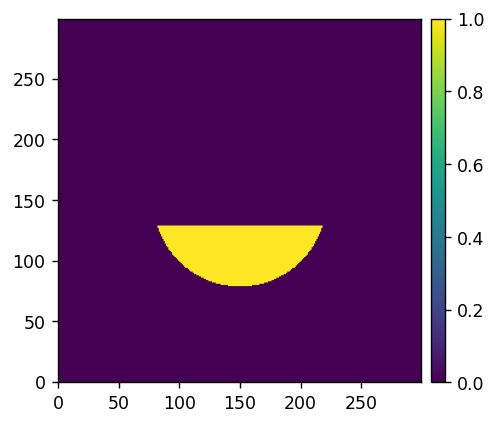

1


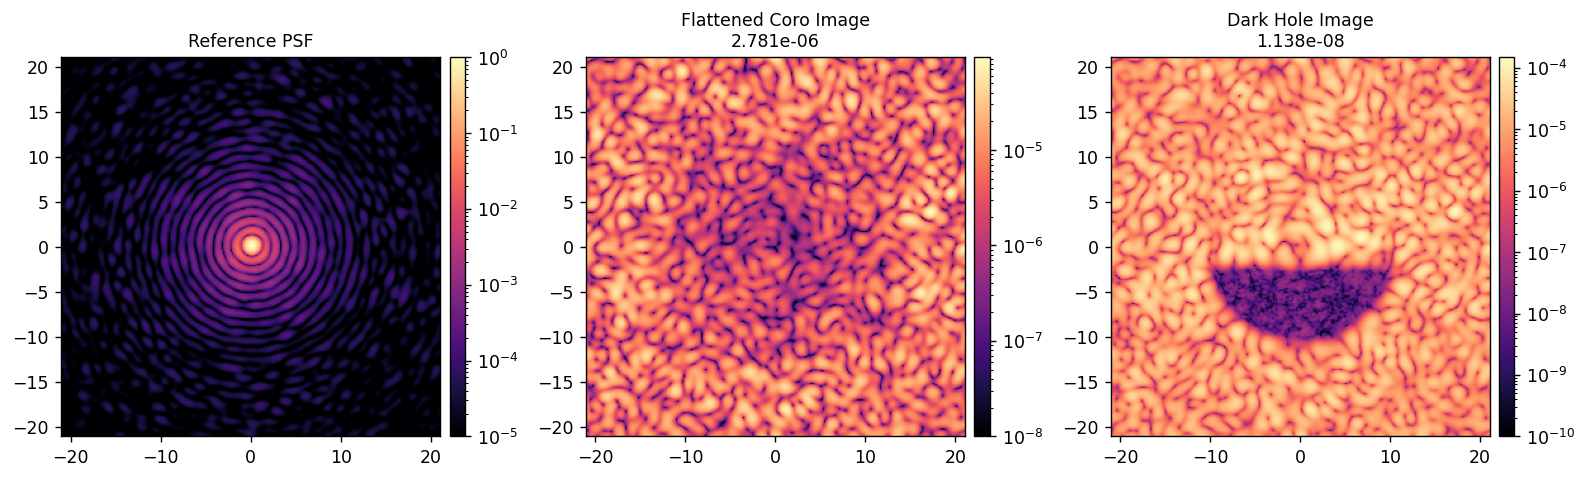

In [39]:
reload(esc)
M = esc.single(
    dm_ref=dm_flat,
    npix=1000, 
    oversample=4.096,
)
M.wfes = wfes
M.npsf = 300

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
coro_im_flat = M.snap()

M.set_dm(dh_command, channel=3)
coro_im_dh = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow([coro_mask])

contrast_flat = utils.mean(coro_im_flat, coro_mask)
contrast_dh = utils.mean(coro_im_dh, coro_mask)

imshow(
    [ref_psf/M.Imax_ref, coro_im_flat, coro_im_dh],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Flattened Coro Image\n{contrast_flat:.3e}', 
            f'Dark Hole Image\n{contrast_dh:.3e}'],
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-8), LogNorm(vmin=1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

In [27]:
(30*u.mas / M.as_per_lamD).decompose().value

np.float64(0.48442258118650516)

1


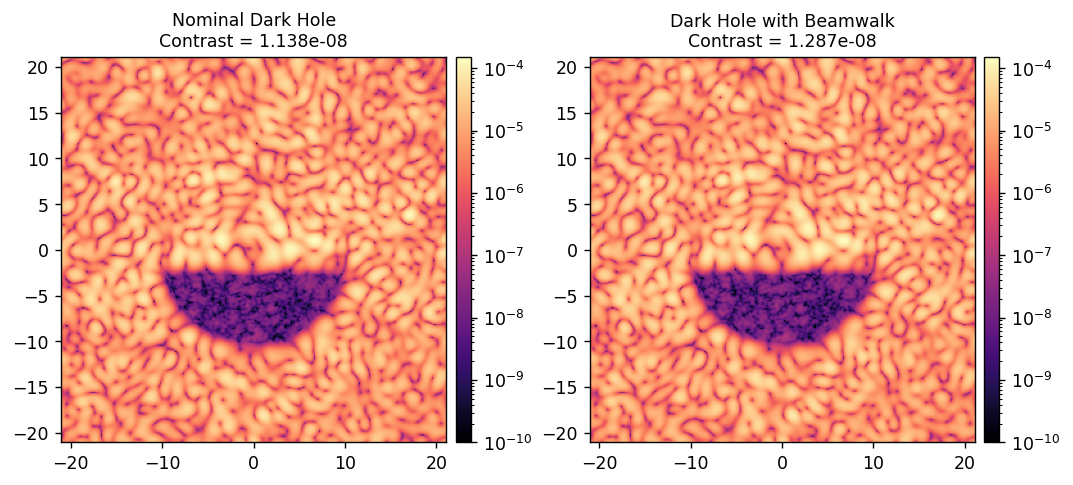

In [36]:
xoffset = -0.
yoffset = -0.1

M.source_offset = (0, 0)
M.set_fsm( [0,0] )
M.reset_dm()
M.set_dm(dh_command, channel=3)
dh0 = M.snap()
contrast0 = xp.mean(dh0[coro_mask])

M.source_offset = (xoffset, yoffset)
M.set_fsm( -np.array([xoffset, yoffset]) )
dh_with_beamwalk = M.snap()
contrast_with_beamwalk = xp.mean(dh_with_beamwalk[coro_mask])

imshow(
    [dh0, dh_with_beamwalk],
    titles=[f'Nominal Dark Hole\nContrast = {contrast0:.3e}', f'Dark Hole with Beamwalk\nContrast = {contrast_with_beamwalk:.3e}'],
    norms=[LogNorm(1e-10)]*2,
    cmaps=['magma']*2,
    pxscls=[M.camsci_pxscl_lamDc]*2,

)

In [40]:
tilt = 100*u.mas

x_field_bias = 1.100000000000000E-001
y_field_bias = 0
x_field_with_tilt = x_field_bias + tilt.to_value(u.degree)
y_field_with_tilt = y_field_bias + tilt.to_value(u.degree)
print(x_field_bias)

print(x_field_with_tilt)
print(y_field_with_tilt)

0.11
0.11002777777777778
2.7777777777777782e-05


# Expected jitter/pointing error is 40mas before M4, 10mas bewteen M4 and FSM, and then 5mas for the rest.

# Perform an initial propagation to compute a reference PSF that is used to normalize the coronagraphic images. 

In [ ]:

start_row = 22
end_row = 128 - 22

surf_nums = np.loadtxt(
    esc_fresnel.path/'esc_ray_on_axis.txt', 
    skiprows=start_row, 
    max_rows=end_row, 
    usecols=0, 
    encoding="utf-16", 
    dtype=int,
)

xc_on_axis = np.loadtxt(esc_fresnel.path/'esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_on_axis = np.loadtxt(esc_fresnel.path/'esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_off_axis_x = np.loadtxt(esc_fresnel.path/'esc_ray_off_axis_x_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_off_axis_x = np.loadtxt(esc_fresnel.path/'esc_ray_off_axis_x_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_off_axis_y = np.loadtxt(esc_fresnel.path/'esc_ray_off_axis_y_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_off_axis_y = np.loadtxt(esc_fresnel.path/'esc_ray_off_axis_y_100mas.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)



In [22]:
reload(esc_optics)

seed = 1234
optic_keys = list(esc_optics.zemax_inds.keys())
beamwalk_matrices = {}
for i in range(len(optic_keys)):
    surf_num = esc_optics.zemax_inds[optic_keys[i]]
    surf_ind = np.where(surf_num==surf_nums)[0][0]
    print(optic_keys[i])
    print(surf_num, surf_ind)

    M_bw = np.array([
        [xc_off_axis_x[surf_ind] - xc_on_axis[surf_ind], xc_off_axis_y[surf_ind] - xc_on_axis[surf_ind]],
        [yc_off_axis_x[surf_ind] - yc_on_axis[surf_ind], yc_off_axis_y[surf_ind] - yc_on_axis[surf_ind]]
    ]) * u.mm/ (100*u.mas)
    print(M_bw)

    beamwalk_matrices.update({optic_keys[i]: M_bw})


m1
4 3
[[-5.79800001e-07 -1.00000079e-10]
 [ 0.00000000e+00 -5.80000001e-07]] mm / mas
m2
5 4
[[ 3.63267000e-05 -1.03900000e-07]
 [ 2.20000004e-09  3.65406000e-05]] mm / mas
m3
6 5
[[ 3.920100e-04 -1.548200e-06]
 [-2.643000e-07  3.928213e-04]] mm / mas
m4
9 8
[[-2.44680e-07  6.24770e-07]
 [ 5.66590e-07  3.46977e-06]] mm / mas
wcc_fp
12 11
[[-4.80732370e-04 -7.25330000e-06]
 [-7.26935360e-06 -4.87234212e-04]] mm / mas
oap1
21 20
[[-6.6755237e-04  1.6391500e-06]
 [ 1.6110000e-06 -6.6342110e-04]] mm / mas
fm1
23 22
[[-4.8935312e-04  1.1368300e-06]
 [ 1.1142000e-06 -5.1517780e-04]] mm / mas
pupil_mask
27 26
[[-2.85240421e-07 -9.36825043e-06]
 [ 7.71833134e-06  2.85781731e-07]] mm / mas
oap2
30 29
[[ 4.89050000e-07 -6.33778400e-05]
 [ 6.56712093e-05 -4.99861941e-07]] mm / mas
ifp1
32 31
[[ 2.77920900e-07 -9.88472321e-05]
 [ 9.52987251e-05 -2.78383590e-07]] mm / mas
oap3
35 34
[[ 1.02610000e-07 -1.17423790e-04]
 [ 1.17069335e-04 -1.15898646e-07]] mm / mas
fsm
38 37
[[-3.37766956e-07  3.65853

1


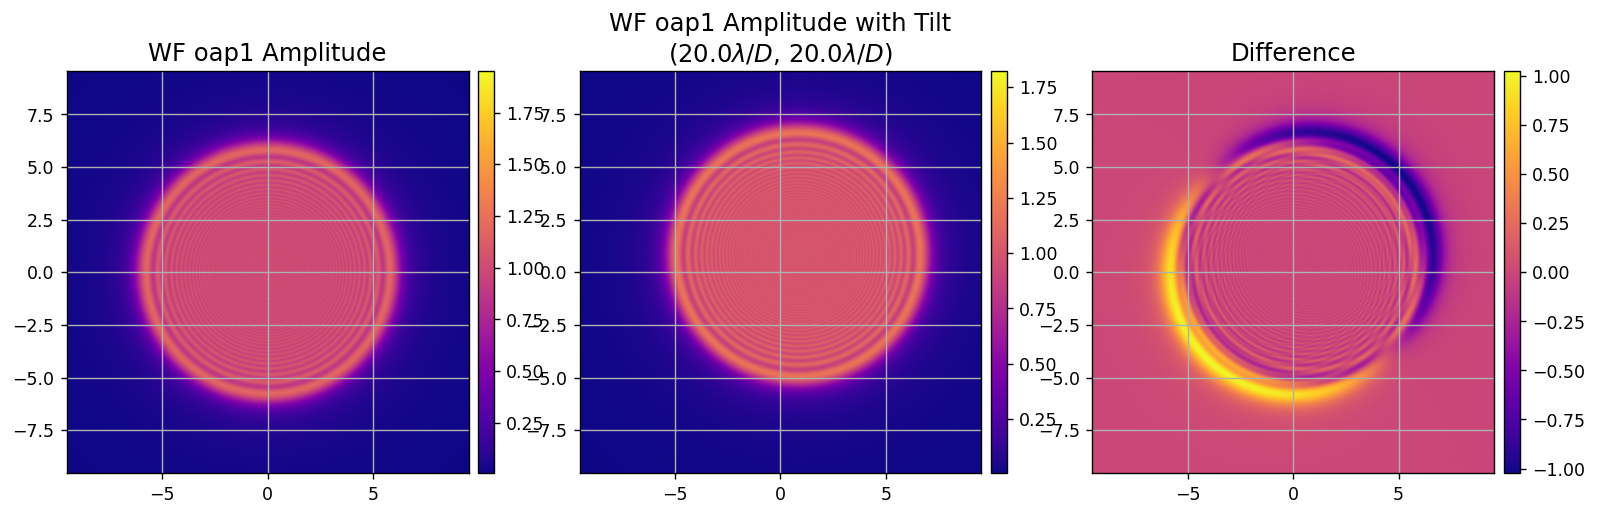

In [24]:
import copy 

M = esc.single()

i = 6
i = 4 # m3
i = 7 # oap1
# i = 13
# i = 25

source_offset = np.array([20, 20])

M.use_vortex = False

M.source_offset = (0, 0)
wfs_on_axis = M.calc_wfs()

M.source_offset = source_offset
wfs_offset = M.calc_wfs()

amp1 = wfs_on_axis[i].amplitude
amp2 = wfs_offset[i].amplitude
diff = amp1 - amp2

wf_pxscl_mm = wfs_on_axis[i].pixelscale.to_value(u.mm/u.pix)

# ticks = np.arange(-15, 15.01, 5)

imshow(
    [amp1, amp2, diff],
    titles=[
        f'WF {wfs_on_axis[i].location[6:]} Amplitude',
        f'WF {wfs_on_axis[i].location[6:]} Amplitude with Tilt\n({M.source_offset[0]:.1f}$\lambda/D$, {M.source_offset[1]:.1f}$\lambda/D$)',
        'Difference',
    ],
    title_fzs=[14]*3,
    # norms=[LogNorm(1e-6), LogNorm(1e-6)],
    npix=[1.5*M.npix]*3,
    grids=[1]*3,
    pxscls=[wf_pxscl_mm]*3,
    # xticks=[ticks, ticks],
    # yticks=[ticks, ticks],
    cmaps=['plasma']*3,
)

In [25]:
pointing = source_offset * M.as_per_lamD
print(pointing)
expected_shift_mm = beamwalk_matrices['oap1'].dot(pointing.to(u.mas)).to_value(u.mm)
print(expected_shift_mm)

shift_pix, error, phasediff = phase_cross_correlation(
    ensure_np_array(amp1), 
    ensure_np_array(amp2),
    upsample_factor=10,
)

shift_mm = np.flip(shift_pix) * wf_pxscl_mm
print(shift_mm)

[1.23858801 1.23858801] arcsec
[-0.82479213 -0.81971005]
[-0.82209792 -0.82209792]


[1.23858801 1.23858801] arcsec
[ 0.09677112 -0.09608134]
[-0.09538231 -0.09538231]
1


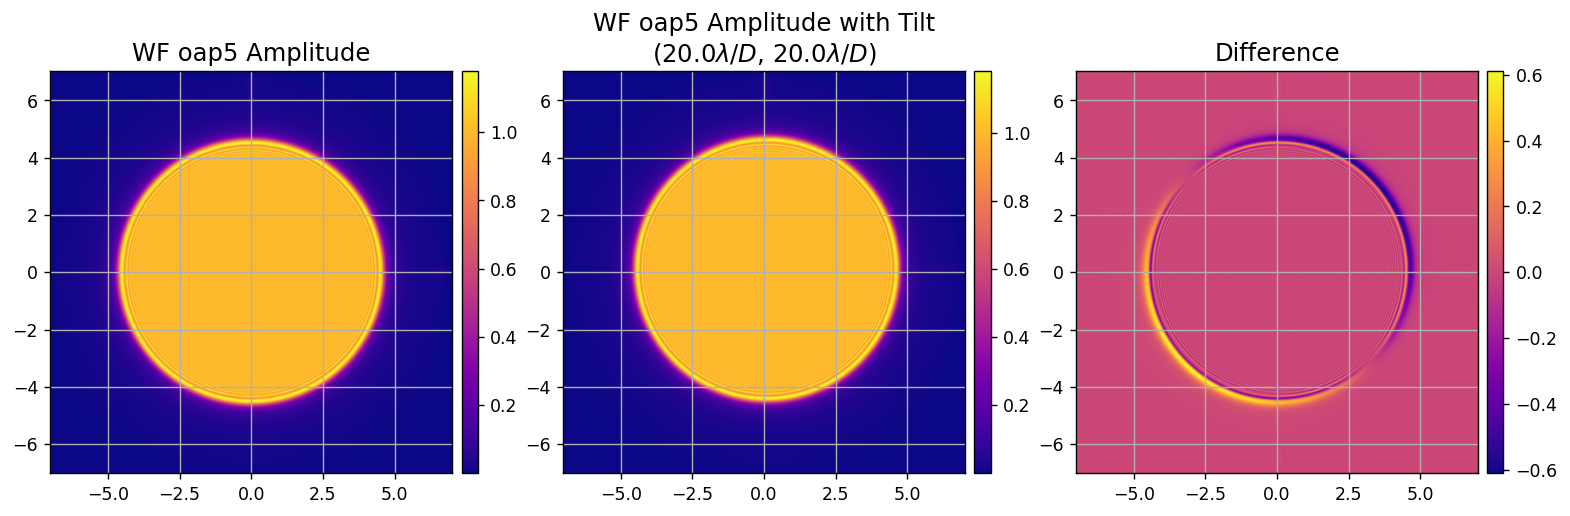

In [28]:
i = 18

pointing = source_offset * M.as_per_lamD
print(pointing)

amp1 = wfs_on_axis[i].amplitude
amp2 = wfs_offset[i].amplitude
diff = amp1 - amp2

wf_pxscl_mm = wfs_on_axis[i].pixelscale.to_value(u.mm/u.pix)

expected_shift_mm = beamwalk_matrices['oap5'].dot(pointing.to(u.mas)).to_value(u.mm)
print(expected_shift_mm)

shift_pix, error, phasediff = phase_cross_correlation(
    ensure_np_array(amp1), 
    ensure_np_array(amp2),
    upsample_factor=10,
)

shift_mm = np.flip(shift_pix) * wf_pxscl_mm
print(shift_mm)

# ticks = np.arange(-15, 15.01, 5)

imshow(
    [amp1, amp2, diff],
    titles=[
        f'WF {wfs_on_axis[i].location[6:]} Amplitude',
        f'WF {wfs_on_axis[i].location[6:]} Amplitude with Tilt\n({M.source_offset[0]:.1f}$\lambda/D$, {M.source_offset[1]:.1f}$\lambda/D$)',
        'Difference',
    ],
    title_fzs=[14]*3,
    # norms=[LogNorm(1e-6), LogNorm(1e-6)],
    npix=[1.5*M.npix]*3,
    grids=[1]*3,
    pxscls=[wf_pxscl_mm]*3,
    # xticks=[ticks, ticks],
    # yticks=[ticks, ticks],
    cmaps=['plasma']*3,
)

In [29]:
pointing = source_offset * M.as_per_lamD
print(pointing)

for i in range(len(wfs_on_axis)):
    optic_name = wfs_on_axis[i].location[6:]
    # print(name)
    if optic_name in list(beamwalk_matrices.keys()):
        print(i, optic_name)
        expected_shift_mm = beamwalk_matrices[optic_name].dot(pointing.to(u.mas)).to_value(u.mm)
        total_expected_shift_mm = np.sqrt( expected_shift_mm[0]**2 + expected_shift_mm[1]**2)
        # print(f'Expected shift: ( {expected_shift_mm[0]:.2e}, {expected_shift_mm[1]:.2e} )')
        print(f'Expected shift: {total_expected_shift_mm:.6f}')

        amp1 = wfs_on_axis[i].amplitude
        amp2 = wfs_offset[i].amplitude
        wf_pxscl_mm = wfs_on_axis[i].pixelscale.to_value(u.mm/u.pix)

        shift_pix, error, phasediff = phase_cross_correlation(
            ensure_np_array(amp1), 
            ensure_np_array(amp2),
            upsample_factor=10,
        )

        shift_mm = np.flip(shift_pix) * wf_pxscl_mm
        total_shift_mm = np.sqrt( shift_mm[0]**2 + shift_mm[1]**2)
        # print(f'Measured shift: ( {shift_mm[0]:.2e}, {shift_mm[1]:.2e} )')
        print(f'Measured shift: {total_shift_mm:.6f}')

        print()

        
    

[1.23858801 1.23858801] arcsec
2 m1
Expected shift: 0.001016
Measured shift: 0.000000

3 m2
Expected shift: 0.063730
Measured shift: 0.061522

4 m3
Expected shift: 0.685781
Measured shift: 0.687964

7 oap1
Expected shift: 1.162844
Measured shift: 1.162622

8 fm1
Expected shift: 0.878103
Measured shift: 0.851270

10 oap2
Expected shift: 0.112175
Measured shift: 0.113383

11 ifp1
Expected shift: 0.169577
Measured shift: 0.165851

12 oap3
Expected shift: 0.205181
Measured shift: 0.203658

15 fm2
Expected shift: 0.187821
Measured shift: 0.185144

16 oap4
Expected shift: 0.362292
Measured shift: 0.363676

17 ifp2
Expected shift: 0.288385
Measured shift: 0.249294

18 oap5
Expected shift: 0.136368
Measured shift: 0.134891

20 input_lp
Expected shift: 0.284408
Measured shift: 0.285651

21 input_qwp
Expected shift: 0.296237
Measured shift: 0.309456

22 oap6
Expected shift: 0.471946
Measured shift: 0.497245

25 oap7
Expected shift: 1.265156
Measured shift: 1.259316

28 oap9
Expected shift: 0.365